# Telecom Customer Churn Prediction (Indian Prepaid Data)

**Goal:** Predict which high-value prepaid customers will churn, explain *why*, and turn the predictions into a
business decision (who to target, how much it saves, what to offer).

**Dataset:** Indian telecom churn data, 4 months of usage (June to September), file `telecom_churn_data.csv`
from Kaggle (search: *Telecom Customer Churn Dataset* by shivam131019).

**What makes this project different from a typical churn notebook**

| Step | Why it matters |
|---|---|
| Churn defined from usage (not given) | Mirrors how real telecoms define churn for prepaid users |
| Usage-drop features (month 8 vs months 6 and 7) | Churners reduce usage *before* leaving, a strong early signal |
| Split first, SMOTE only on training data | Avoids the data leakage that inflates many published results |
| 3 models compared with ROC-AUC, PR-AUC, recall | Accuracy alone is misleading on imbalanced data |
| Cost-based decision threshold | Chooses the cut-off that maximises rupees saved, not accuracy |
| SHAP explanations | Shows what drives churn, globally and per customer |
| Revenue at risk and risk segments with actions | Connects the model to a retention campaign |
| Kaplan-Meier retention curves | Shows how churn depends on tenure and usage behaviour |

## 1. Setup

In [5]:
# Uncomment on first run if a library is missing:
# %pip install -q pandas numpy scikit-learn imbalanced-learn xgboost shap matplotlib seaborn joblib

In [6]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [7]:
# ---------------- Configuration (edit here) ----------------
RANDOM_STATE = 42
DATA_PATH = Path("telecom_churn_data.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

HIGH_VALUE_PERCENTILE = 0.70   # keep customers above the 70th percentile of good-phase recharge value
MISSING_THRESHOLD = 0.40       # drop columns with more than 40% missing values
TEST_SIZE = 0.20

# Business assumptions for the cost-based threshold (in rupees, change to match a real business case).
RETENTION_OFFER_COST = 200                    # cost of one retention offer
CUSTOMER_LOSS_VALUE = 5 * RETENTION_OFFER_COST  # acquiring a customer costs about 5x retaining one
OFFER_SUCCESS_RATE = 0.50                     # share of at-risk customers an offer actually saves

In [8]:
# ---------------- Plot style: large, high-contrast, uncluttered ----------------
sns.set_theme(style="whitegrid", context="talk", rc={"axes.grid.axis": "y"})
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 100,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})
COLORS = {"stay": "#1f77b4", "churn": "#d62728", "neutral": "#4d4d4d"}

## 2. Load data

In [9]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"'{path}' not found. Download telecom_churn_data.csv from Kaggle and place it next to this notebook."
        )
    return pd.read_csv(path)


raw = load_data(DATA_PATH)
print(f"Raw data: {raw.shape[0]:,} customers x {raw.shape[1]} columns")
raw.head()

Raw data: 99,999 customers x 226 columns


,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.4,0.0,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.0,0.0,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.0,0.0,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.0,0.0,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.0,0.0,0.00,0.00


In [10]:
missing_pct = (raw.isna().mean() * 100).sort_values(ascending=False)
print("Columns with more than 40% missing:", int((missing_pct > 40).sum()))
missing_pct.head(10).round(1).to_frame("missing %")

Columns with more than 40% missing: 40


,missing %
date_of_last_rech_data_6,74.8
total_rech_data_6,74.8
max_rech_data_6,74.8
count_rech_2g_6,74.8
av_rech_amt_data_6,74.8
count_rech_3g_6,74.8
arpu_3g_6,74.8
arpu_2g_6,74.8
fb_user_6,74.8
night_pck_user_6,74.8


## 3. Define the target: high-value customers and churn

Two business rules (standard for prepaid telecom):

1. **High-value customers**: the top 30% by average recharge value in the "good phase" (months 6 and 7).
   Losing these customers hurts revenue most, so the model focuses on them.
2. **Churn**: a customer who made **no calls (incoming or outgoing) and used no mobile data in month 9**.
   All month-9 columns are then **removed from the features**, because they would leak the answer.

In [11]:
def month_recharge_value(df: pd.DataFrame, month: int) -> pd.Series:
    """Talktime recharge plus data recharge value for one month."""
    talktime = df[f"total_rech_amt_{month}"].fillna(0)
    data = df[f"total_rech_data_{month}"].fillna(0) * df[f"av_rech_amt_data_{month}"].fillna(0)
    return talktime + data


def select_high_value_customers(df: pd.DataFrame, percentile: float) -> pd.DataFrame:
    good_phase_value = (month_recharge_value(df, 6) + month_recharge_value(df, 7)) / 2
    cutoff = good_phase_value.quantile(percentile)
    return df[good_phase_value >= cutoff].copy()


CHURN_COLUMNS = ["total_ic_mou_9", "total_og_mou_9", "vol_2g_mb_9", "vol_3g_mb_9"]


def tag_churn(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["churn"] = (df[CHURN_COLUMNS].fillna(0).sum(axis=1) == 0).astype(int)
    return df


def drop_churn_phase_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Remove every month-9 column (churn phase) so the model cannot peek at the outcome."""
    leak_cols = [c for c in df.columns if c.endswith("_9") or c.startswith("sep_")]
    return df.drop(columns=leak_cols)


high_value = select_high_value_customers(raw, HIGH_VALUE_PERCENTILE)
data = drop_churn_phase_columns(tag_churn(high_value))

print(f"High-value customers: {len(data):,} of {len(raw):,}")
print(f"Churn rate: {data['churn'].mean():.2%}")

High-value customers: 30,001 of 99,999
Churn rate: 8.14%


## 4. Clean the data

- Drop identifiers and date columns.
- A missing value in a recharge-data column means *no data recharge*, so it is filled with 0.
- Drop columns with too many missing values, and columns with a single constant value.
- Remaining gaps are filled with the **median inside the model pipeline** (fitted on training data only).

In [12]:
ID_COLUMNS = ["mobile_number", "circle_id"]
ZERO_FILL_PREFIXES = (
    "total_rech_data_", "max_rech_data_", "count_rech_2g_", "count_rech_3g_", "av_rech_amt_data_",
)


def clean_data(df: pd.DataFrame, missing_threshold: float) -> pd.DataFrame:
    df = df.copy()

    date_cols = [c for c in df.columns if "date" in c]
    df = df.drop(columns=ID_COLUMNS + date_cols, errors="ignore")

    zero_fill_cols = [c for c in df.columns if c.startswith(ZERO_FILL_PREFIXES)]
    df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

    missing_share = df.drop(columns="churn").isna().mean()
    df = df.drop(columns=missing_share[missing_share > missing_threshold].index)

    constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
    return df.drop(columns=constant_cols)


clean = clean_data(data, MISSING_THRESHOLD)
print(f"After cleaning: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

After cleaning: 30,001 rows x 140 columns


## 5. Feature engineering: usage-drop signals

Customers usually **reduce usage and recharges before they leave**. For each key metric we compare
**month 8 (the action phase)** with the **average of months 6 and 7 (the good phase)**:

- `<metric>_good_avg`: average of months 6 and 7
- `<metric>_drop`: month 8 minus the good-phase average (negative means usage fell)
- `<metric>_drop_pct`: the same change as a fraction of the good-phase average (clipped to avoid extreme outliers)

In [13]:
TREND_METRICS = [
    "arpu", "total_og_mou", "total_ic_mou", "total_rech_amt", "total_rech_num",
    "max_rech_amt", "vol_2g_mb", "vol_3g_mb", "onnet_mou", "offnet_mou",
]


def add_usage_drop_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    new_features = {}
    for metric in TREND_METRICS:
        m6, m7, m8 = (f"{metric}_{m}" for m in (6, 7, 8))
        if not all(col in df.columns for col in (m6, m7, m8)):
            continue
        good_avg = (df[m6] + df[m7]) / 2
        new_features[f"{metric}_good_avg"] = good_avg
        new_features[f"{metric}_drop"] = df[m8] - good_avg
        new_features[f"{metric}_drop_pct"] = ((df[m8] - good_avg) / (good_avg + 1)).clip(-1, 5)

    if "aon" in df.columns:
        new_features["tenure_years"] = df["aon"] / 365

    return pd.concat([df, pd.DataFrame(new_features, index=df.index)], axis=1)


model_data = add_usage_drop_features(clean)
engineered = [c for c in model_data.columns if c not in clean.columns]
print(f"Added {len(engineered)} engineered features. Total columns: {model_data.shape[1]}")

Added 31 engineered features. Total columns: 171


## 6. Exploratory analysis

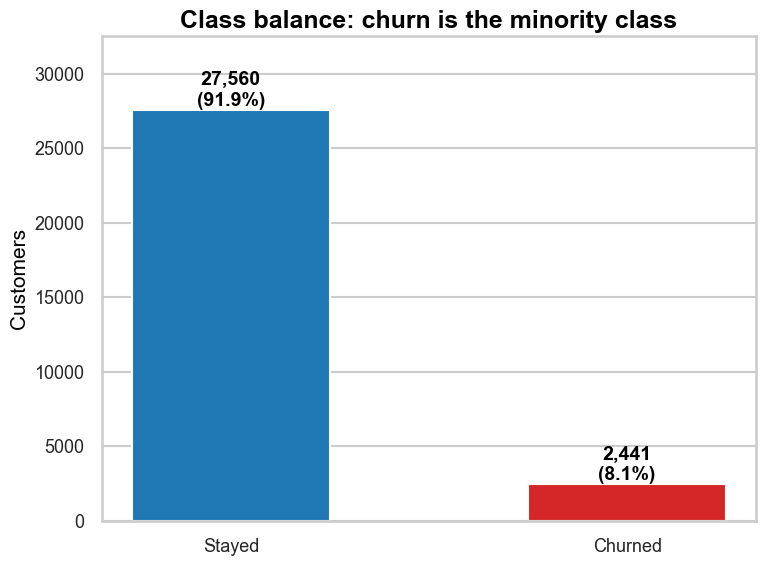

In [14]:
churn_counts = model_data["churn"].value_counts().sort_index()
labels = ["Stayed", "Churned"]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, churn_counts.values, color=[COLORS["stay"], COLORS["churn"]], width=0.5)
for bar, value in zip(bars, churn_counts.values):
    share = value / churn_counts.sum()
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}\n({share:.1%})",
            ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.set_ylim(0, churn_counts.max() * 1.18)
ax.set_ylabel("Customers")
ax.set_title("Class balance: churn is the minority class")
plt.tight_layout()
plt.show()

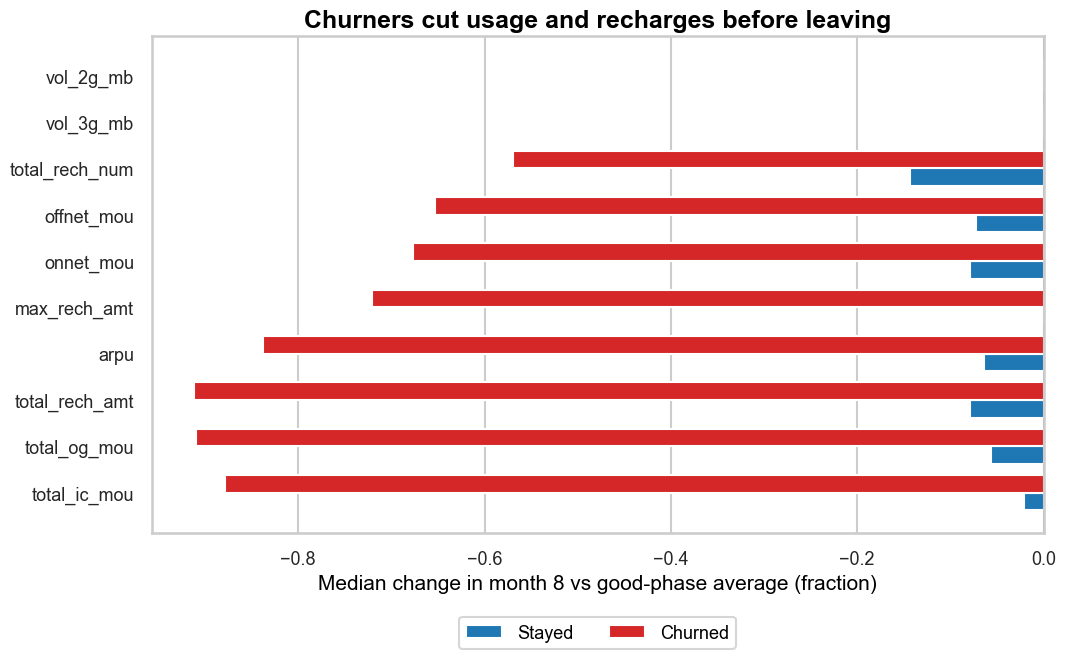

In [15]:
drop_features = [c for c in model_data.columns if c.endswith("_drop_pct")]
median_drop = (
    model_data.groupby("churn")[drop_features].median().T
    .rename(columns={0: "Stayed", 1: "Churned"})
    .assign(gap=lambda d: d["Churned"] - d["Stayed"])
    .sort_values("gap")
)
median_drop.index = [name.replace("_drop_pct", "") for name in median_drop.index]

fig, ax = plt.subplots(figsize=(11, 7))
positions = np.arange(len(median_drop))
height = 0.38
ax.barh(positions - height / 2, median_drop["Stayed"], height, label="Stayed", color=COLORS["stay"])
ax.barh(positions + height / 2, median_drop["Churned"], height, label="Churned", color=COLORS["churn"])
ax.set_yticks(positions)
ax.set_yticklabels(median_drop.index)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Median change in month 8 vs good-phase average (fraction)")
ax.set_title("Churners cut usage and recharges before leaving")
ax.grid(axis="y", visible=False)
ax.grid(axis="x")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

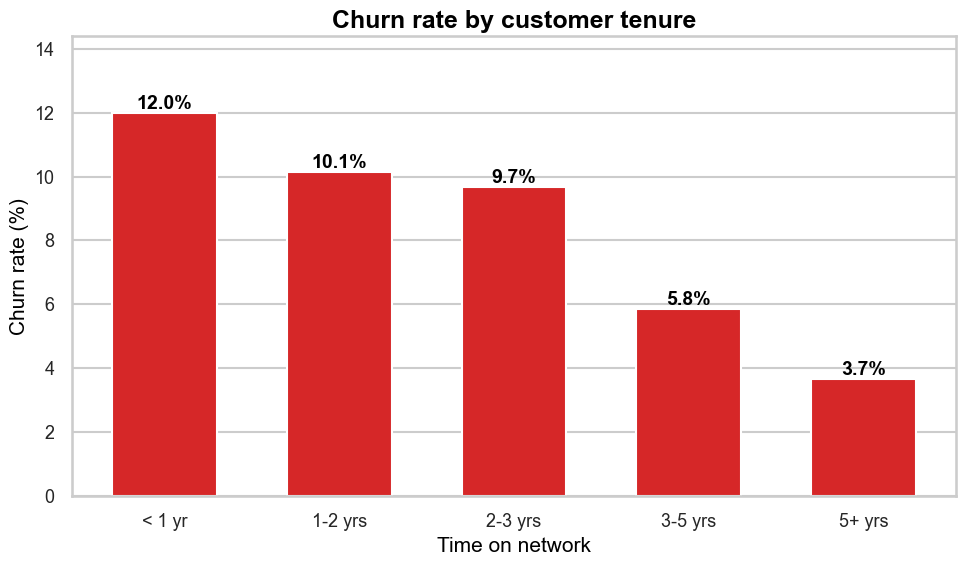

In [16]:
if "tenure_years" in model_data.columns:
    bands = pd.cut(model_data["tenure_years"], bins=[0, 1, 2, 3, 5, 100],
                   labels=["< 1 yr", "1-2 yrs", "2-3 yrs", "3-5 yrs", "5+ yrs"])
    churn_by_tenure = model_data.groupby(bands, observed=True)["churn"].mean() * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values, color=COLORS["churn"], width=0.6)
    for bar, value in zip(bars, churn_by_tenure.values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}%",
                ha="center", va="bottom", fontsize=14, fontweight="bold")
    ax.set_ylim(0, churn_by_tenure.max() * 1.2)
    ax.set_xlabel("Time on network")
    ax.set_ylabel("Churn rate (%)")
    ax.set_title("Churn rate by customer tenure")
    plt.tight_layout()
    plt.show()

## 7. Train/test split, then balance only the training data

The split happens **first**. SMOTE (synthetic minority oversampling) is placed *inside* the training pipeline, so
synthetic customers never appear in the test set and never leak into evaluation.

In [17]:
X = model_data.drop(columns="churn")
y = model_data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows (churn {y_train.mean():.2%})")
print(f"Test : {X_test.shape[0]:,} rows (churn {y_test.mean():.2%})")

Train: 24,000 rows (churn 8.14%)
Test : 6,001 rows (churn 8.13%)


## 8. Train and compare three models

In [18]:
def build_pipeline(model, scale: bool = False) -> Pipeline:
    """Median imputation -> (optional scaling) -> SMOTE on training data only -> model."""
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps += [
        ("smote", SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)),
        ("model", model),
    ]
    return Pipeline(steps)


models = {
    "Logistic Regression": build_pipeline(
        LogisticRegression(max_iter=1000, C=0.1), scale=True
    ),
    "Random Forest": build_pipeline(
        RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
        )
    ),
    "XGBoost": build_pipeline(
        XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE,
        )
    ),
}

In [19]:
def evaluate(y_true, proba, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "Recall (churners caught)": recall_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred),
        "Accuracy": accuracy_score(y_true, pred),
    }


test_proba, results = {}, {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    test_proba[name] = pipeline.predict_proba(X_test)[:, 1]
    results[name] = evaluate(y_test, test_proba[name])

results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
results_df.round(3)

  File "c:\Users\Y Veera Vardhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Y Veera Vardhan\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Y Veera Vardhan\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, p

,ROC-AUC,PR-AUC,Recall (churners caught),Precision,F1,Accuracy
Random Forest,0.931,0.672,0.641,0.622,0.632,0.939
XGBoost,0.928,0.674,0.605,0.669,0.635,0.944
Logistic Regression,0.901,0.591,0.719,0.461,0.562,0.909


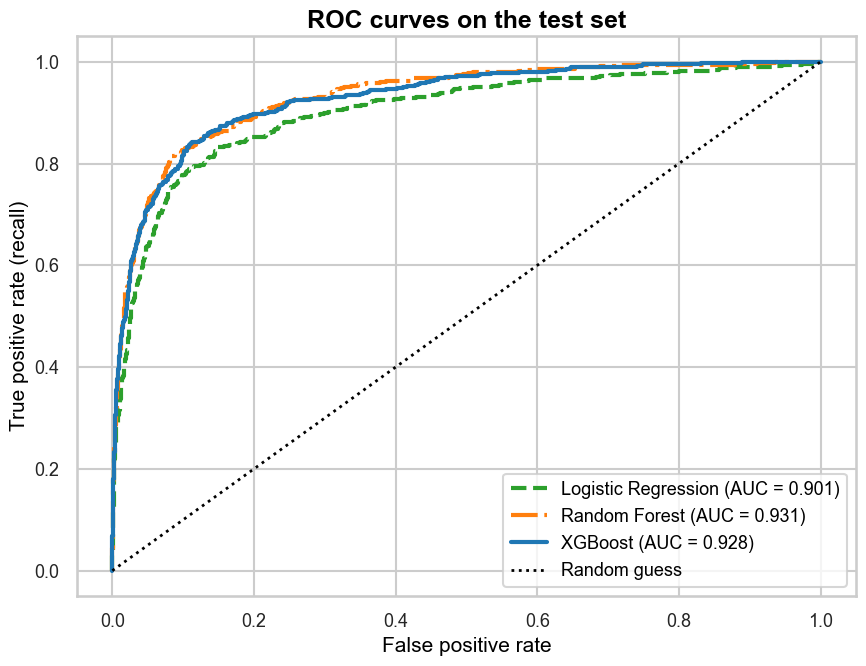

In [20]:
line_styles = {"Logistic Regression": "--", "Random Forest": "-.", "XGBoost": "-"}
line_colors = {"Logistic Regression": "#2ca02c", "Random Forest": "#ff7f0e", "XGBoost": "#1f77b4"}

fig, ax = plt.subplots(figsize=(9, 7))
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linestyle=line_styles[name], color=line_colors[name], linewidth=3,
            label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=2, label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.set_title("ROC curves on the test set")
ax.grid(True)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best model by ROC-AUC: Random Forest


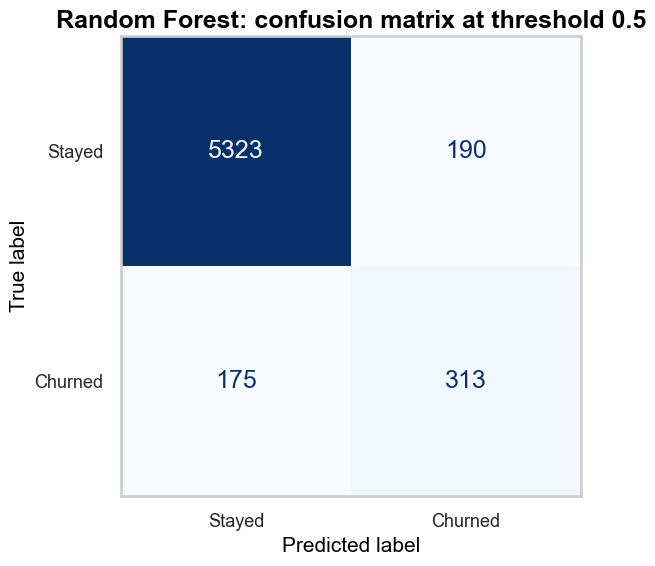

In [21]:
best_name = results_df["ROC-AUC"].idxmax()
best_pipeline = models[best_name]
print(f"Best model by ROC-AUC: {best_name}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, (test_proba[best_name] >= 0.5).astype(int),
    display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax, colorbar=False,
    text_kw={"fontsize": 18},
)
ax.set_title(f"{best_name}: confusion matrix at threshold 0.5")
ax.grid(False)
plt.tight_layout()
plt.show()

## 10. Explain the model with SHAP

SHAP shows how much each feature pushes a customer's churn score up or down. We explain the best
tree-based model on a sample of test customers.

In [25]:
tree_models = [name for name in ("Random Forest", "XGBoost") if name in results_df.index]
explain_name = results_df.loc[tree_models, "ROC-AUC"].idxmax()
explain_pipeline = models[explain_name]
print(f"Explaining: {explain_name}")

imputer = explain_pipeline.named_steps["imputer"]
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), columns=imputer.get_feature_names_out(), index=X_test.index
)
X_sample = X_test_imputed.sample(min(1500, len(X_test_imputed)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(explain_pipeline.named_steps["model"])
shap_values = explainer(X_sample, check_additivity=False)
if shap_values.values.ndim == 3:          # some models return one set of values per class
    shap_values = shap_values[:, :, 1]

Explaining: Random Forest


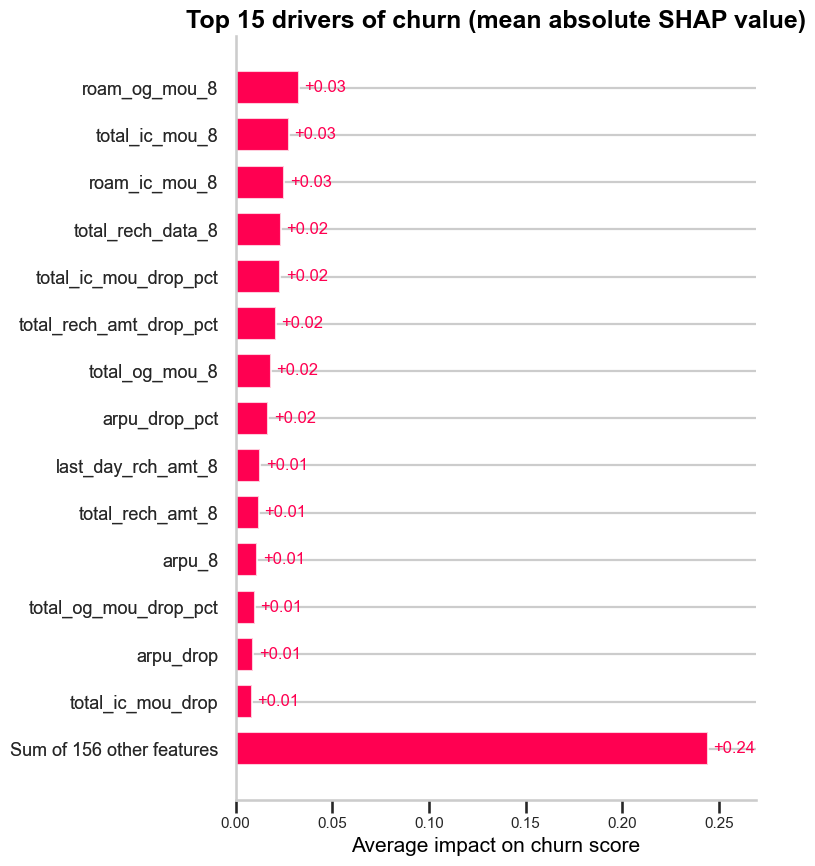

In [26]:
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Top 15 drivers of churn (mean absolute SHAP value)", fontsize=18, fontweight="bold")
plt.xlabel("Average impact on churn score", fontsize=15)
plt.tight_layout()
plt.show()

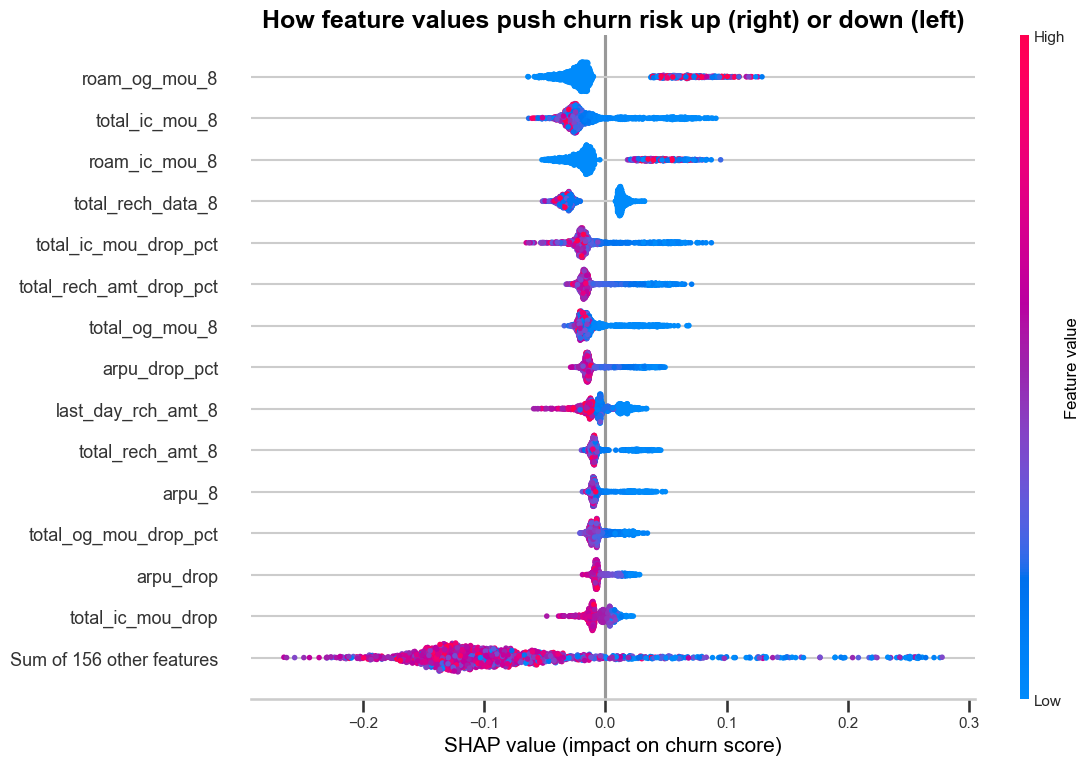

In [27]:
shap.plots.beeswarm(shap_values, max_display=15, show=False, plot_size=(12, 8))
plt.title("How feature values push churn risk up (right) or down (left)", fontsize=18, fontweight="bold")
plt.xlabel("SHAP value (impact on churn score)", fontsize=15)
plt.tight_layout()
plt.show()

Customer with the highest churn probability in the sample: 98.7%


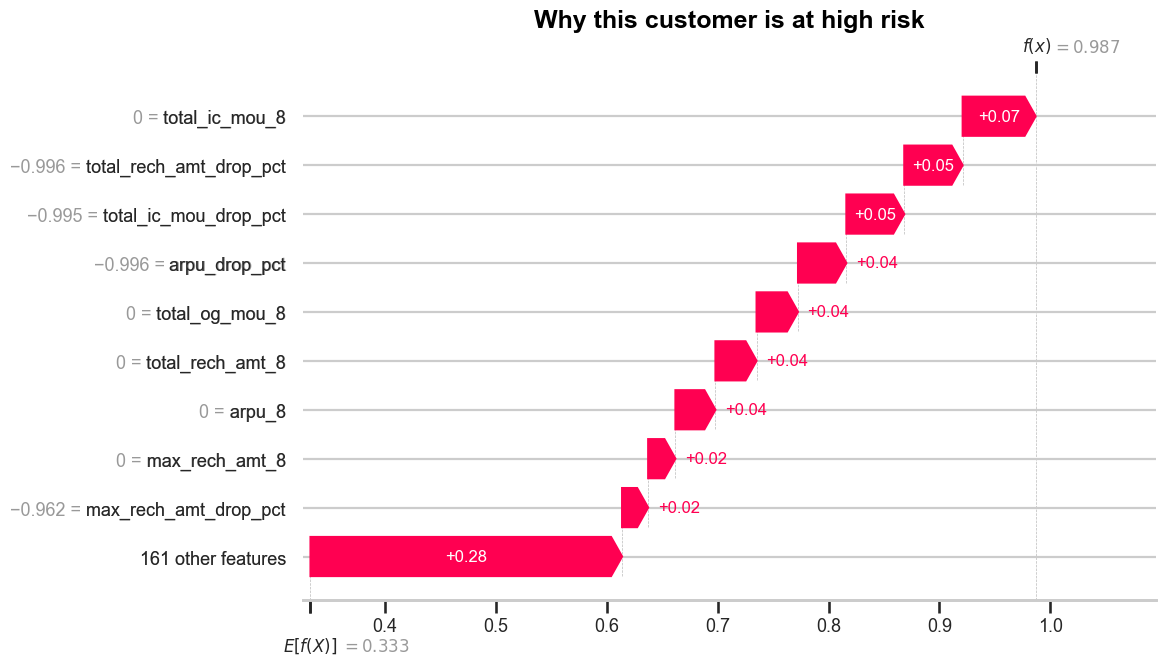

In [28]:
# Explain a single high-risk customer
sample_scores = explain_pipeline.predict_proba(X_sample.to_numpy())[:, 1]
riskiest = int(np.argmax(sample_scores))
print(f"Customer with the highest churn probability in the sample: {sample_scores[riskiest]:.1%}")

shap.plots.waterfall(shap_values[riskiest], max_display=10, show=False)
plt.gcf().set_size_inches(12, 7)
plt.title("Why this customer is at high risk", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()